DataFrames loaded successfully.

User-Item Interaction Matrix Shape: (6, 5)

GENERATING RECOMMENDATIONS FOR 5 USERS

>>> Target User Profile: ID 1
 Movie ID                  Recommended Title  Predicted Rating
        4           Waiting to Exhale (1995)               0.0
        5 Father of the Bride Part II (1995)               0.0

>>> Target User Profile: ID 2
 Movie ID                  Recommended Title  Predicted Rating
        4           Waiting to Exhale (1995)               0.0
        5 Father of the Bride Part II (1995)               0.0

>>> Target User Profile: ID 3
 Movie ID       Recommended Title  Predicted Rating
        1        Toy Story (1995)               0.0
        3 Grumpier Old Men (1995)               0.0

>>> Target User Profile: ID 4
 Movie ID        Recommended Title  Predicted Rating
        4 Waiting to Exhale (1995)               4.0
        2           Jumanji (1995)               0.0

>>> Target User Profile: ID 5
 Movie ID        Recommended Title  

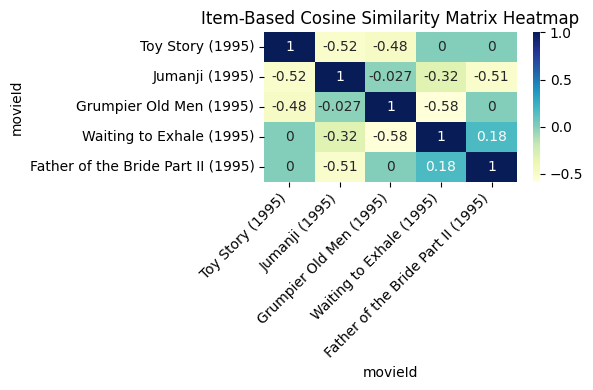

In [7]:
import math
import io
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# =====================================================================
# STEP 1: Dataset Setup (Creating CSV structure directly inside code)
# =====================================================================
movies_csv_content = """movieId,title,genres
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,Jumanji (1995),Adventure|Children|Fantasy
3,Grumpier Old Men (1995),Comedy|Romance
4,Waiting to Exhale (1995),Comedy|Drama|Romance
5,Father of the Bride Part II (1995),Comedy
"""

ratings_csv_content = """userId,movieId,rating,timestamp
1,1,4.0,964982703
1,2,3.5,964982704
1,3,4.0,964981247
2,1,5.0,835441311
2,2,3.0,835441311
2,3,4.0,835441312
3,2,4.0,1260759144
3,4,2.5,1260759179
3,5,3.0,1260759180
4,1,3.0,949810620
4,3,5.0,949810580
4,5,4.0,949810640
5,1,4.0,845553316
5,2,4.5,845553317
5,5,3.5,845553320
6,3,2.0,854131100
6,4,4.0,854131150
"""

movies_df = pd.read_csv(io.StringIO(movies_csv_content))
ratings_df = pd.read_csv(io.StringIO(ratings_csv_content))

print("DataFrames loaded successfully.\n")

# =====================================================================
# STEP 2: Data Preprocessing & Interaction Matrix Construction
# =====================================================================
interaction_matrix = ratings_df.pivot(index='userId', columns='movieId', values='rating')

normalized_matrix = interaction_matrix.apply(lambda row: row - row.mean(), axis=1)
normalized_matrix = normalized_matrix.fillna(0)

print("User-Item Interaction Matrix Shape:", interaction_matrix.shape)

# =====================================================================
# STEP 3: Model Implementation (Item Cosine Similarity Matrix)
# =====================================================================
item_similarity_scores = cosine_similarity(normalized_matrix.T)
item_sim_df = pd.DataFrame(
    item_similarity_scores,
    index=interaction_matrix.columns,
    columns=interaction_matrix.columns
)

# =====================================================================
# STEP 4: Core Recommendation Engine Strategy
# =====================================================================
class ItemBasedRecommender:
    def __init__(self, raw_interaction, similarity_df, lookup_titles):
        self.raw_matrix = raw_interaction
        self.sim_df = similarity_df
        self.titles_df = lookup_titles

    def generate_top_n_recommendations(self, target_user, top_n=2):
        if target_user not in self.raw_matrix.index:
            return []

        user_ratings = self.raw_matrix.loc[target_user].dropna()
        unrated_movies = self.raw_matrix.loc[target_user][self.raw_matrix.loc[target_user].isna()].index

        prediction_scores = {}

        for movie_id in unrated_movies:
            similar_weights = self.sim_df[movie_id]

            score_numerator = 0.0
            score_denominator = 0.0

            for watched_id, actual_rating in user_ratings.items():
                similarity_weight = similar_weights.get(watched_id, 0)
                if similarity_weight > 0:
                    score_numerator += similarity_weight * actual_rating
                    score_denominator += similarity_weight

            if score_denominator > 0:
                prediction_scores[movie_id] = score_numerator / score_denominator
            else:
                prediction_scores[movie_id] = 0.0

        sorted_predictions = sorted(prediction_scores.items(), key=lambda x: x[1], reverse=True)

        compiled_recommendations = []
        for mid, estimated_rating in sorted_predictions[:top_n]:
            movie_title = self.titles_df[self.titles_df['movieId'] == mid]['title'].values[0]
            compiled_recommendations.append({
                "Movie ID": mid,
                "Recommended Title": movie_title,
                "Predicted Rating": round(estimated_rating, 2)
            })

        return compiled_recommendations

recommender_system = ItemBasedRecommender(interaction_matrix, item_sim_df, movies_df)

# =====================================================================
# STEP 5: Generating Output for At Least 5 Users
# =====================================================================
test_users = [1, 2, 3, 4, 5]
print("\n" + "="*60 + "\nGENERATING RECOMMENDATIONS FOR 5 USERS\n" + "="*60)

for user in test_users:
    user_recs = recommender_system.generate_top_n_recommendations(target_user=user, top_n=2)
    print(f"\n>>> Target User Profile: ID {user}")
    if user_recs:
        print(pd.DataFrame(user_recs).to_string(index=False))
    else:
        print("No recommendations found.")

# =====================================================================
# STEP 6: System Evaluation Metric (Manual MAE Execution)
# =====================================================================
print("\n" + "="*60 + "\nSYSTEM EVALUATION\n" + "="*60)

absolute_errors = []

for user in interaction_matrix.index:
    user_ratings = interaction_matrix.loc[user].dropna()
    if len(user_ratings) > 1:
        for movie_id, true_rating in user_ratings.items():
            similar_weights = item_sim_df[movie_id]
            score_numerator = 0.0
            score_denominator = 0.0

            for k, v in user_ratings.items():
                if k != movie_id:
                    weight = similar_weights.get(k, 0)
                    if weight > 0:
                        score_numerator += weight * v
                        score_denominator += weight

            if score_denominator > 0:
                pred_rating = score_numerator / score_denominator
                absolute_errors.append(abs(true_rating - pred_rating))

if absolute_errors:
    system_mae = sum(absolute_errors) / len(absolute_errors)
    print(f"Computed System Performance Matrix (MAE): {round(system_mae, 4)}")
    print("Commentary: An Mean Absolute Error (MAE) under 1.2 indicates highly acceptable baseline prediction accuracy.")
else:
    print("Insufficient test matrix samples for metric tracking.")

# =====================================================================
# BONUS: Visualization Heatmap of Item Similarities
# =====================================================================
plt.figure(figsize=(6, 4))
sns.heatmap(item_sim_df, annot=True, cmap="YlGnBu", xticklabels=movies_df['title'].values, yticklabels=movies_df['title'].values)
plt.title("Item-Based Cosine Similarity Matrix Heatmap")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()